# Analyse et justification de K

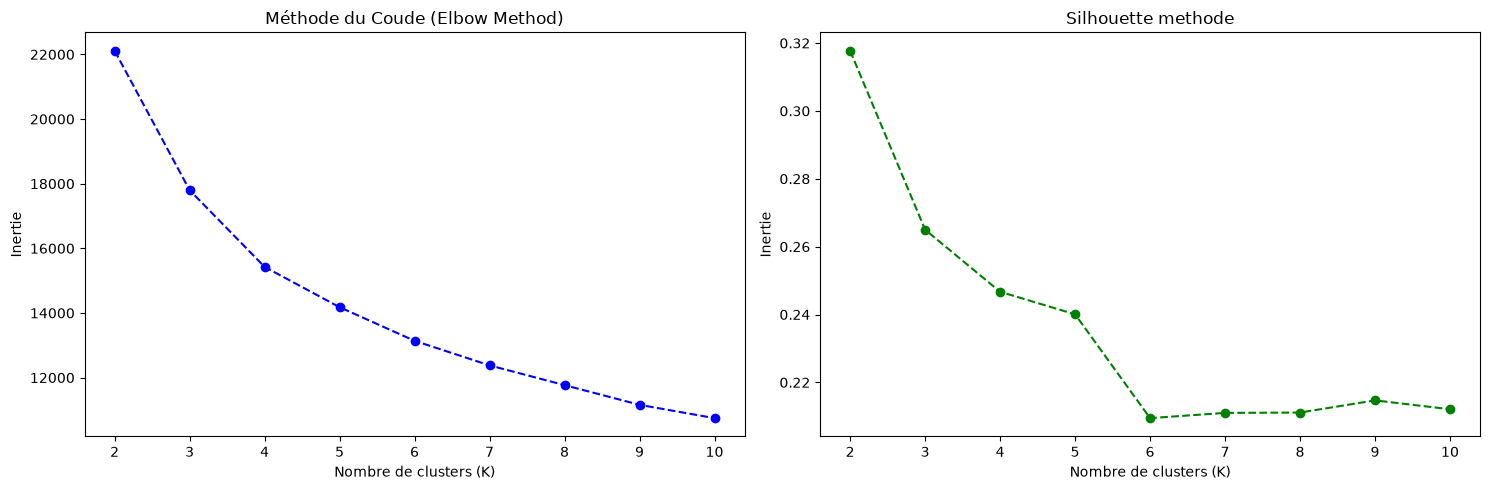

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

ROOT_DIR = Path.cwd().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))
from src import config

# chargement des données d'entrainement
df_train = pd.read_csv(config.PROCESSED_DATA_DIR / "telco_features.csv")


# separation des features de la cible

cols_to_drop = [config.TARGET_COL, config.ID_COL]
cols_to_drop = [col for col in cols_to_drop if col in df_train.columns]
X_cluster = df_train.drop(columns=cols_to_drop)
# if config.TARGET_COL in df_train.columns:
#     X_cluster = df_train.drop(columns=[config.TARGET_COL])
# else:
#     X_cluster = df_train.copy()

# calcul des inertie et le socre de silhouette
inertias = []
silhouettee_score = []
k_range = range(2,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouettee_score.append(silhouette_score(X_cluster, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].plot(k_range, inertias, marker='o', linestyle='--', color='blue')
axes[0].set_title('Méthode du Coude (Elbow Method)')
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')

axes[1].plot(k_range, silhouettee_score, marker='o', linestyle='--', color='green')
axes[1].set_title('Silhouette methode')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Inertie')


plt.tight_layout()
plt.show()


# Comparaison DBSCAN & Agglomerative Clustering.

In [10]:
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src import config


df = pd.read_csv(config.PROCESSED_DATA_DIR / "telco_features.csv")
cols_to_drop = [col for col in [config.TARGET_COL, config.ID_COL] if col in df.columns]
X = df.drop(columns=cols_to_drop)

# 2 define the models
k = 4
models = {
    "KMeans": KMeans(n_clusters=k, random_state=42, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=k),
    "DBSCAN": DBSCAN(eps=2.8, min_samples=10)
}


results = []

for name, model in models.items():

    labels = model.fit_predict(X)


    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters_found > 1:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        results.append({
            "Algorithm": name, 
            "Clusters Found": n_clusters_found,
            "Silhouette": round(sil, 3),
            "Davies-Bouldin": round(db, 3),
            "Calinski-Harabasz": round(ch, 1)
        })

    else:
        results.append({
            "Algorithm": name, 
            "Clusters Found": n_clusters_found,
            "Silhouette": "N/A",
            "Davies-Bouldin": "N/A",
            "Calinski-Harabasz": "N/A"
        })


    results_df = pd.DataFrame(results)
    print("=== CLUSTERING ALGORITHM EVELUATION ===")
    print(results_df.to_string(index=False))

=== CLUSTERING ALGORITHM EVELUATION ===
Algorithm  Clusters Found  Silhouette  Davies-Bouldin  Calinski-Harabasz
   KMeans               4       0.247           1.414             2833.8
=== CLUSTERING ALGORITHM EVELUATION ===
    Algorithm  Clusters Found  Silhouette  Davies-Bouldin  Calinski-Harabasz
       KMeans               4       0.247           1.414             2833.8
Agglomerative               4       0.181           1.604             2191.8
=== CLUSTERING ALGORITHM EVELUATION ===
    Algorithm  Clusters Found Silhouette Davies-Bouldin Calinski-Harabasz
       KMeans               4      0.247          1.414            2833.8
Agglomerative               4      0.181          1.604            2191.8
       DBSCAN               1        N/A            N/A               N/A
